# Pr-YBCO version Fit modes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from importlib import reload
import no_distort_C2_alris_one_third_functions as no_distort_C2_alris_one_third_functions
reload(no_distort_C2_alris_one_third_functions)
from no_distort_C2_alris_one_third_functions import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list
from matplotlib.markers import MarkerStyle
from time import time

tf.keras.utils.set_random_seed(1)

Define the function containing the fitting parameters

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- `fun_tf()` correspond to the **structure factor calculation function** (one has to convert it to a **TF-compatible** function)
- <span style="color:red">If conversion to TF-compatible function is not possible, then this approach will probably not work (or becomes much more tedious at least)</span>

In [2]:
def fn_all_hkl_list():
    all_h_list = np.linspace(0 , -4.666666 , 15)
    all_k_list = np.linspace(0 , 4.666666 , 15) 
    all_l_list = np.linspace(0 , 12 , 5) 
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = tf.convert_to_tensor(all_hkl_list, dtype=tf.float32)
    return all_hkl_list

In [3]:
def make_hkl_indices(hkl_list , experimental_data):

    
    hkl_list = np.array(hkl_list, dtype=np.float32) * 3
    hkl_list = pd.DataFrame(hkl_list, columns=['h', 'k', 'l'])

    #turn all values into integers
    hkl_list = hkl_list.astype(int)

    print('hkl')
    print(hkl_list)
    print('hkl_list shape')
    print(hkl_list.shape)

    all_h_list = np.linspace(0 , -4.666666 , 15) * 3
    all_k_list = np.linspace(0 , 4.666666 , 15) * 3
    all_l_list = np.linspace(0 , 12 , 5) * 3
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = np.round(all_hkl_list).astype(int)
    all_hkl_list = pd.DataFrame(all_hkl_list, columns=['h', 'k', 'l'])


    # all_hkl_list = all_hkl_list.astype(int)
    print('all_hkl')
    print(all_hkl_list)

    merged = all_hkl_list.merge(hkl_list, how='left', indicator=True)
    hkl_indices = merged[merged['_merge'] == 'both'].index.tolist()

    print('hkl_indices')
    print(hkl_indices)

    #retrive hkl values from all_hkl_list using hkl_indices
    hkl_from_indices = all_hkl_list.iloc[hkl_indices].values.tolist()

    print('hkl_from_indices')
    print(hkl_from_indices)

    reordered_hkl_list = pd.DataFrame(hkl_from_indices, columns=['h', 'k', 'l'])


    experimental_data[['h', 'k', 'l']] = experimental_data[['h', 'k', 'l']] * 3 
    experimental_data[['h', 'k', 'l']] = np.round(experimental_data[['h', 'k', 'l']]).astype(int)

    print('reordered_hkl_list')
    print(reordered_hkl_list)

    print('hkl_indices')
    print(hkl_indices)

    print('hkl_indices length')
    print(len(hkl_indices))

    #find the intensity values from experimental_data corresponding to the reordered_hkl_list
    intensity = []
    for index, row in reordered_hkl_list.iterrows():
        h = row['h']
        k = row['k']
        l = row['l']
        intensity_value = experimental_data[(experimental_data['h'] == h) & (experimental_data['k'] == k) & (experimental_data['l'] == l)]['intensity_exp'].values
        print('intensity_value')
        print(intensity_value)
        
        if len(intensity_value) > 0:
            intensity.append(intensity_value[0])
        else:
            intensity.append(0)

    reordered_hkl_list = np.array(hkl_from_indices, dtype=np.float32) / 3

    hkl_indices = tf.convert_to_tensor(hkl_indices, dtype=tf.int32)

    return hkl_indices , reordered_hkl_list , intensity

In [4]:
mode_num = 102
structure_type = 'C2'

path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type

# experimental_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv')
experimental_data2 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no_bragg.csv')

# print(max(experimental_data2['intensity_exp']))

hkl_list = experimental_data2[["h", "k", "l"]].values.tolist()

print('hkl_list')
print(hkl_list)


hkl_indices , hkl_list , intensity_reordered = make_hkl_indices(hkl_list , experimental_data2)
experimental_data = pd.DataFrame(hkl_list , columns=['h', 'k', 'l'])
experimental_data['intensity_exp'] = intensity_reordered

print('reordered hkl_list')
print(hkl_list)

hkl_list = tf.convert_to_tensor(hkl_list, dtype=tf.float32)


path_matrix = path + '/C2_matrix.txt'
matrix = np.loadtxt(path_matrix, dtype=np.float32)
matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)

hkl_list
[[-0.333333333, 1.0, 0.0], [-0.666666667, 1.0, 0.0], [-1.333333333, 1.0, 0.0], [-2.333333333, 1.0, 0.0], [-2.666666667, 1.0, 0.0], [-3.333333333, 1.0, 0.0], [-3.666666667, 1.0, 0.0], [-4.333333333, 1.0, 0.0], [-4.666666667, 1.0, 0.0], [-1.0, 1.333333333, 0.0], [-3.0, 1.333333333, 0.0], [-2.0, 1.666666667, 0.0], [-4.0, 1.666666667, 0.0], [-0.333333333, 2.0, 0.0], [-1.666666667, 2.0, 0.0], [-2.333333333, 2.0, 0.0], [-2.666666667, 2.0, 0.0], [-3.333333333, 2.0, 0.0], [-3.666666667, 2.0, 0.0], [-0.666666667, 2.333333333, 0.0], [-1.0, 2.333333333, 0.0], [-2.0, 2.333333333, 0.0], [-3.0, 2.333333333, 0.0], [-4.0, 2.333333333, 0.0], [-1.0, 2.666666667, 0.0], [-2.0, 2.666666667, 0.0], [-3.0, 2.666666667, 0.0], [-1.333333333, 3.0, 0.0], [-2.333333333, 3.0, 0.0], [-2.666666667, 3.0, 0.0], [-3.333333333, 3.0, 0.0], [-4.333333333, 3.0, 0.0], [-4.666666667, 3.0, 0.0], [-1.0, 3.333333333, 0.0], [-2.0, 3.333333333, 0.0], [-3.0, 3.333333333, 0.0], [-4.0, 3.333333333, 0.0], [-2.0, 3.666666667, 

Sample the "training data" (features and labels)

<span style="color:yellow">Note on actual unit cell structure refinement problem:</span>
- The features are the (h,k,l) coordinates (e.g. a vector of size `n_features` x 3, i.e. `n_dim = 3`)
- Maybe one has to normalize the features (i.e. not using integers but floats between -1 (0) and 1)? Before passing them to the structure calculation function, they should be again rescaled to integers
- The labels would be the experimental intensities (again, maybe have to be normalized to the range between 0 and 1)

Sum of labels: 1157.705746653
Max label ERR: 20.065367
min label ERR: 0.01616863
Features shape: (302, 3)
Labels shape: (302, 1)
error shape: (302, 1)
Max label: 61.84816
min label : 0.049837116


(array([191.,  63.,  20.,  14.,   5.,   3.,   3.,   0.,   1.,   0.,   1.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.]),
 array([ 0.        ,  1.26220734,  2.52441469,  3.78662203,  5.04882937,
         6.31103671,  7.57324406,  8.8354514 , 10.09765874, 11.35986608,
        12.62207343, 13.88428077, 15.14648811, 16.40869545, 17.6709028 ,
        18.93311014, 20.19531748, 21.45752483, 22.71973217, 23.98193951,
        25.24414685, 26.5063542 , 27.76856154, 29.03076888, 30.29297622,
        31.55518357, 32.81739091, 34.07959825, 35.34180559, 36.60401294,
        37.86622028, 39.12842762, 40.39063496, 41.65284231, 42.91504965,
        44.17725699, 45.43946434, 46.70167168, 47.96387902, 49.22608636,
        50.48829371, 51.75050105, 53.01270839, 54.27491573, 55.53712308,
       

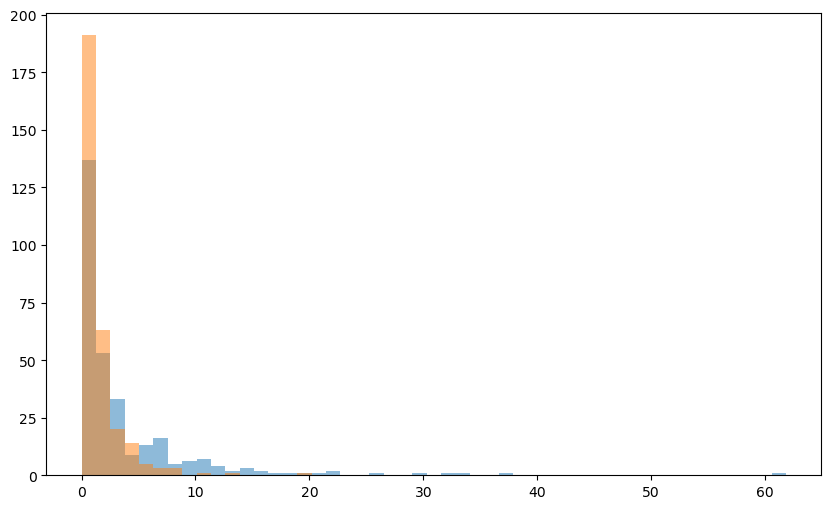

In [14]:
n_features = experimental_data.shape[0]
n_dim = 3

features = hkl_list
labels = experimental_data["intensity_exp"].tolist()
vol_err = experimental_data2["intensity_exp_err"].tolist()

print("Sum of labels:", np.sum(labels))
#labels = np.array(labels, dtype=np.float32)
#labels = labels / np.float32(10446.12988) * 100 #Normalize labels
#labels = labels / np.sum(labels) * 100  # Normalize to sum to 60

# labels = labels / np.float32(149709.010190213) * 100

labels_err = []

for label, err in zip(labels, vol_err):
    if label == 0:
        labels_err.append(1e-9)  # Assign a high error for zero labels
    else:
        labels_err.append(1/label)
        # labels_err.append((label**3)  ) # Normalize error to sum to 60
        #labels_err.append(np.abs((5000 - (1/label * 100))))  # Inverse error for each label

labels_tgt = [labels, labels_err]
labels_tgt = np.transpose(labels_tgt)
labels_err = tf.convert_to_tensor(labels_err, dtype=tf.float32)
labels = tf.convert_to_tensor(labels, dtype=tf.float32)

labels = tf.expand_dims(labels, axis=-1)  # Ensure labels are 2D
labels_err = tf.expand_dims(labels_err, axis=-1)  # Ensure labels_err are 2D

print("Max label ERR:", np.max(labels_err))
print("min label ERR:", np.min(labels_err))
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)
print('error shape:', labels_err.shape)
print("Max label:", np.max(labels))
print("min label :", np.min(labels))
#bin from0 to 0.0025 with 50 bins
plt.figure(figsize=(10, 6))

plt.hist(labels.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels')
plt.hist(labels_err.numpy(), bins=np.linspace(0 , np.max(labels) , 50), alpha=0.5, label='Labels Error')


In [19]:
def fun_tf(hkl_list, pars, matrix):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """
    # stack parameters
    pars_tensor = tf.stack(pars)  # shape (params,)

    atom_shift_list = shift_atoms(matrix , (pars_tensor))
    atom_shift_list = atom_shift_list[:,0]
    atom_shift_list = tf.unstack(atom_shift_list)

    modified_struct = atom_position_list(*atom_shift_list)
    all_hkl_list = fn_all_hkl_list()
    all_hkl_list = transform_list_hkl_p63_p65(all_hkl_list)

    # Get structure factors
    sf_hkl = get_structure_factors(all_hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(all_hkl_list, tf.float32), axis=1)
    intensity = intensity * tf.exp(- w * qnorms ** 2)  # Apply Debye-Waller factor

    all_sim_intensity = intensity * 100
    #sim_intensity = intensity / tf.reduce_max(intensity)  # Normalize to max intensity
    # print(tf.reduce_sum(all_sim_intensity))

    # all_sim_intensity = all_sim_intensity / tf.reduce_max(all_sim_intensity) * 100

    # Extract only the intensities corresponding to the input hkl_list
    sim_intensity = tf.gather(all_sim_intensity, hkl_indices)

    print(len(sim_intensity))

    return sim_intensity



In [20]:
best_model_pars = np.zeros(102, dtype=np.float32)  # Initialize with zeros
#random initialization
best_model_pars[4] = 1.73

best_model_pars = tf.convert_to_tensor(best_model_pars, dtype=tf.float32)   
experimental_data['intensity_sim'] = fun_tf(features , best_model_pars , matrix).numpy()


302


In [21]:
def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100
    
    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['normalised_exp'] + 1)* 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    # ax.scatter(exp_data_0['h'], exp_data_0['k'], 
    #         s=exp_data_0['intensity_sim'] * 100, color='red', edgecolor="black",
    #         label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    # ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=exp_data_0['normalised_exp'] * 100, color='blue', edgecolor="black",
    #         label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def plot_plane_sim_vs_exp_DIM3_no_bragg(ax, df, r_factor, l, norm_plane=False):
    exp_data_0 = df.loc[df['l'] == l].copy()
    #copy the dataframe and remove rows where h and k are both integer
    exp_data_0 = exp_data_0[~((exp_data_0['h'] % 1 == 0) & (exp_data_0['k'] % 1 == 0))]
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100

    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 500 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['normalised_exp'] + 1) * 500 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))
    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

def alris_r_factor(data):
    exp_intensity = data['intensity_exp'] / np.max(data['intensity_exp'])
    exp_intensity = exp_intensity / np.sum(exp_intensity) * 100
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor

ALRIS R-factor: 1.244


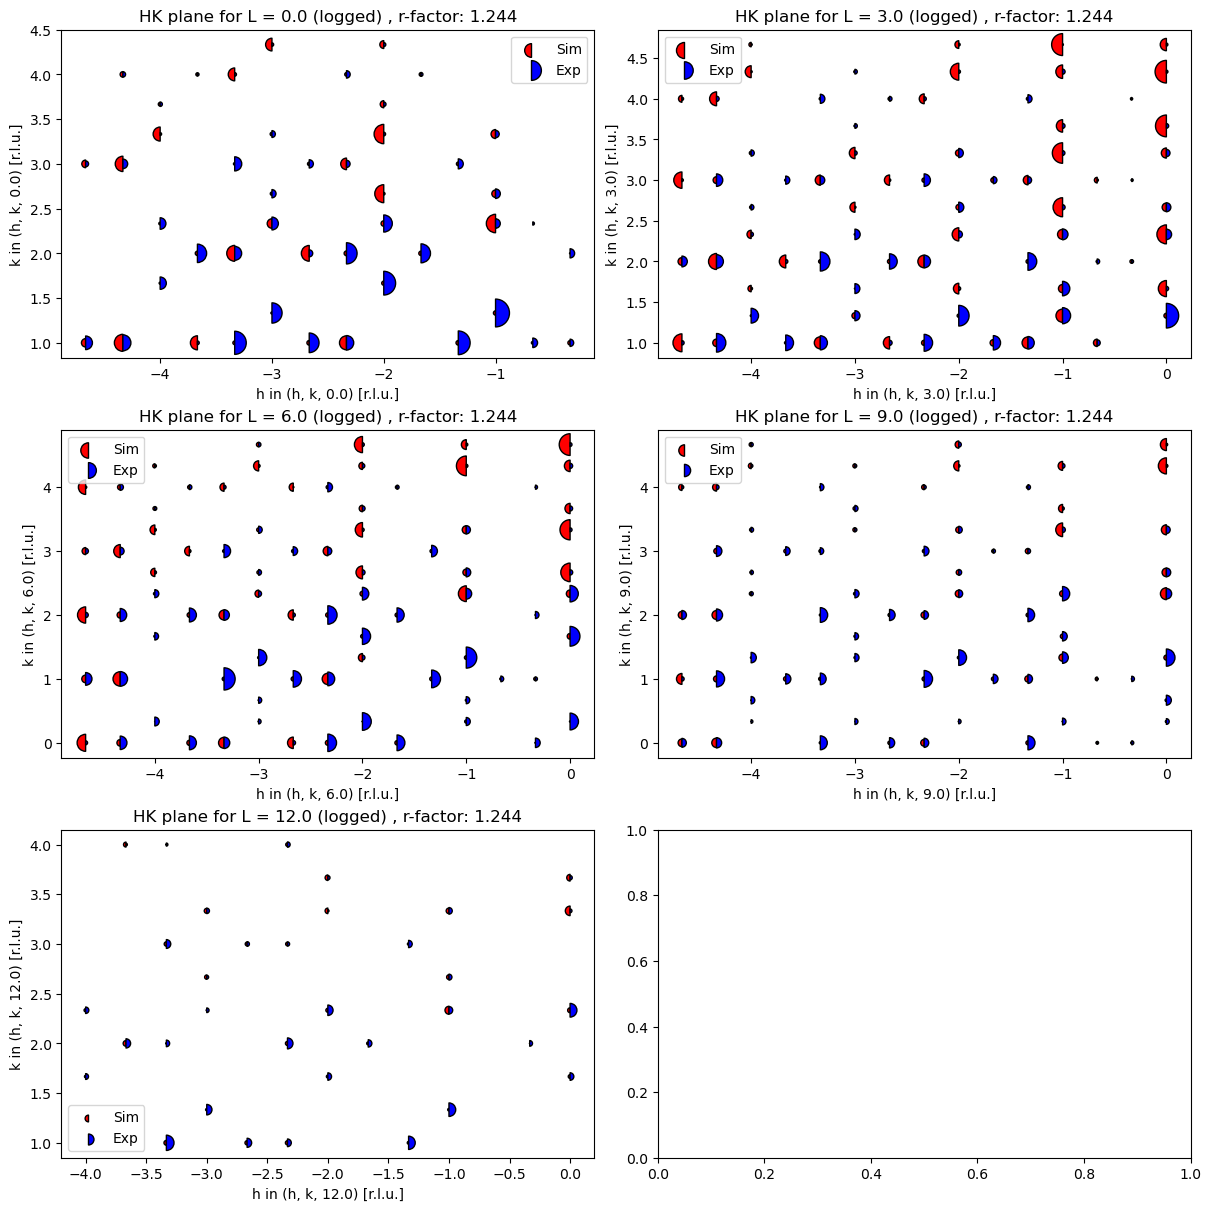

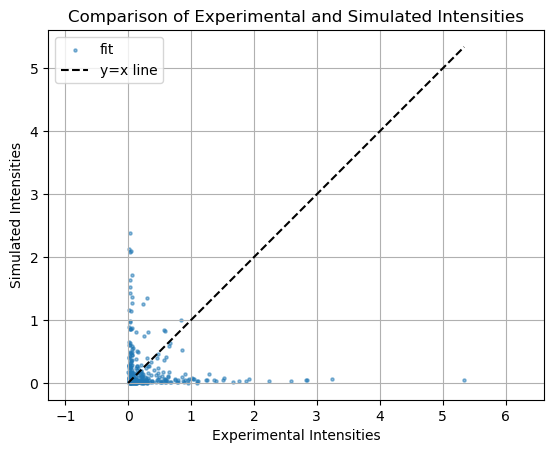

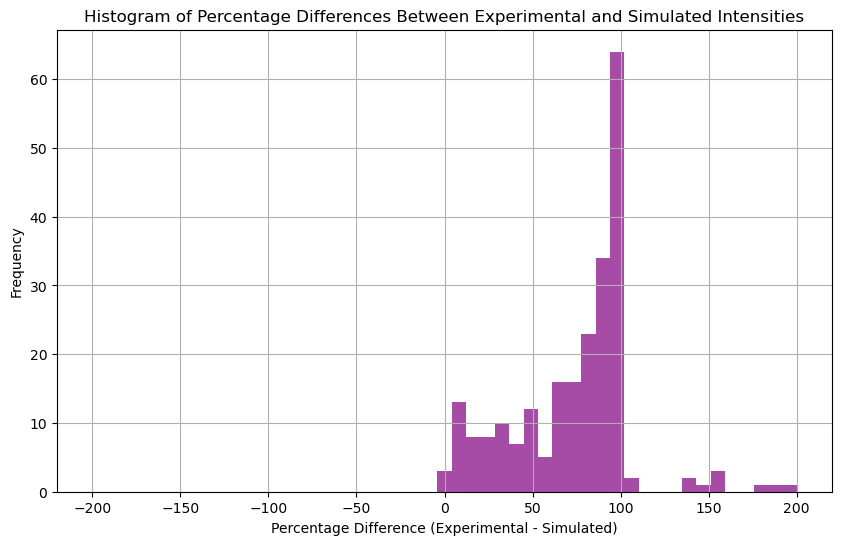

In [22]:
r_factor = alris_r_factor(experimental_data)
print(f"ALRIS R-factor: {r_factor:.3f}")

normalised_exp_data = experimental_data['intensity_exp'] / np.sum(experimental_data['intensity_exp']) * 100
experimental_data['normalised_exp'] = normalised_exp_data
experimental_data['intensity_exp_err'] = labels_err.numpy()

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], experimental_data, r_factor,l, norm_plane=False)

plt.show()

# fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
# axs = axs.flatten()
# for i, l in enumerate(l_values):
#     plot_plane_sim_vs_exp_DIM3_no_bragg(axs[i], experimental_data, r_factor,l, norm_plane=False)
# plt.show()

normalised_exp = experimental_data['intensity_exp']/np.sum(experimental_data['intensity_exp']) * 100

x = np.linspace(0 ,max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, experimental_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - experimental_data['intensity_sim']) / normalised_exp * 100
experimental_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()